In [ ]:
""" Created on November 13, 2023 // Updated on March 20, 2026 // @author: Sarah Shi """

import os
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

import mineralML as mm

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## mineralML Quickstart

This notebook shows **how to load and run your data through mineralML** with an example CSV: `training_hundred.csv`. This is a three step process: 
1. Load a CSV with `load_df` (or `pd.read_csv` directly).
2. Clean and align columns with `prep_df_nn`.
3. Run data through the neural network with `predict_class_prob_nnwr` to derive classifications and prediction scores. 
4. Project data into latent space with `plot_z2_overlay`, for visualization. 

We loaded in the ``mineralML`` Python package as ``mm``. ``mineralML`` has trained machine learning models for classifying minerals. This implementation aims to get your electron microprobe or quantitative EDS compositions classified and processed. We remove some degrees of freedom to simplify the process as much as possible. The minerals considered for this study include: Amphibole, Apatite, Biotite, Calcite, Chlorite, Epidote, Feldspar (KFeldspar and Plagioclase), Garnet, Glass, Kalsilite, Leucite, Melilite, Muscovite, Nepheline, Olivine, Pyroxene (Clinopyroxene and Orthopyroxene), Quartz, Rhombohedral_Oxides (Hematite-Ilmenite), Rutile, Serpentine, Spinels (Magnetite-Spinel), Titanite, Tourmaline, and Zircon. 

One CSV file containing your electron microprobe analyses in oxide weight percentages is necessary. Find an example [here](https://github.com/sarahshi/mineralML/blob/main/docs/examples/training_hundred.csv). The necessary oxides are $SiO_2$, $TiO_2$, $Al_2O_3$, $FeO_t$, $MnO$, $MgO$, $CaO$, $Na_2O$, $K_2O$, $Cr_2O_3$, $P_2O_5$, and $ZrO_2$ (if classifying zircon). For the oxides not analyzed for specific minerals, the preprocessing will fill in the nan values as 0. 

We will apply the neural network method to the dataset. 

# Sequential, Transfer Learning Neural Network Model (Bayesian Neural Network with Variational Inference, and Reconstruction)

## Load and prepare data for analysis

In [8]:
# Read in your dataframe of mineral data, called training_hundred.csv. 
# Prepare the dataframe by removing rows with too many NaNs, and filling in zeros. 

df_load = mm.load_df('training_hundred.csv')
df_nn = mm.prep_df_nn(df_load)

/var/folders/k_/fnnxsv2n52qb5r1hq85f3p2c0000gn/T/ipykernel_31410/1206821658.py:5: UserWarning: Some non-numeric values were found in the oxides columns and have been coerced to NaN.
  df_nn = mm.prep_df_nn(df_load)


In [9]:
# Examine the prepared dataframe

display(df_nn.head())

,Sample Name,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,P2O5,Cr2O3,ZrO2,Mineral,Source
0,Z2099,42.96,1.80,14.33,4.07,0.07,17.39,12.03,3.10,0.03,0.0,0.65,0.0,Amphibole,Vannuccietal1995
1,Z2070,43.03,2.39,13.35,4.09,0.06,17.01,11.71,2.97,0.05,0.0,0.74,0.0,Amphibole,Vannuccietal1995
2,Z2073,42.95,3.02,14.12,4.35,0.06,17.53,12.02,3.04,0.07,0.0,0.76,0.0,Amphibole,Vannuccietal1995
3,Z2067,43.01,4.65,12.83,4.39,0.07,17.14,12.14,2.88,0.03,0.0,0.84,0.0,Amphibole,Vannuccietal1995
4,Z2068,42.13,4.87,12.15,4.08,0.05,16.42,11.89,2.75,0.02,0.0,1.26,0.0,Amphibole,Vannuccietal1995


## Apply the trained neural network

In [10]:
# The trained neural network can be applied in just one line. It returns predictions in columns called "Predict_Mineral", "Submineral" (if applicable, for pyroxenes, feldspars, and oxides), "Predict_Probability", "Second_Predict_Mineral", "Second_Predict_Probability".

df_pred_nn, probability_matrix = mm.predict_class_prob_nnwr(df_nn)

/Users/sarahshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/hybrid.py:1938: RuntimeWarning: invalid value encountered in sqrt
  std_matrix = np.sqrt(probs_var.detach().cpu().numpy())


In [11]:
# Examine the predicted mineral classifications

display(df_pred_nn)

,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,Cr2O3,...,ZrO2,Mineral,Source,Sample Name,Predict_Mineral,Submineral,Prediction_Score,Prediction_Score_Sigma,Second_Predict_Mineral,Second_Prediction_Score
0,42.96,1.80,14.33,4.07,0.07,17.39,12.03,3.10,0.03,0.65,...,0.0,Amphibole,Vannuccietal1995,Z2099,Amphibole,NaN,0.987091,0.035239,Pyroxene,0.009078
1,43.03,2.39,13.35,4.09,0.06,17.01,11.71,2.97,0.05,0.74,...,0.0,Amphibole,Vannuccietal1995,Z2070,Amphibole,NaN,0.987806,0.023982,Glass,0.005804
2,42.95,3.02,14.12,4.35,0.06,17.53,12.02,3.04,0.07,0.76,...,0.0,Amphibole,Vannuccietal1995,Z2073,Amphibole,NaN,0.975507,0.053275,Glass,0.006093
3,43.01,4.65,12.83,4.39,0.07,17.14,12.14,2.88,0.03,0.84,...,0.0,Amphibole,Vannuccietal1995,Z2067,Amphibole,NaN,0.991660,0.017491,Pyroxene,0.003232
4,42.13,4.87,12.15,4.08,0.05,16.42,11.89,2.75,0.02,1.26,...,0.0,Amphibole,Vannuccietal1995,Z2068,Amphibole,NaN,0.991795,0.013485,Glass,0.003941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,50.39,1.71,13.95,12.55,0.22,6.90,11.78,2.41,0.33,0.00,...,0.0,Glass,Hartleyetal2013,23B-03,Glass,NaN,0.998472,0.003513,Amphibole,0.001089
2796,49.30,1.66,13.99,11.94,0.21,7.16,12.04,2.16,0.32,0.00,...,0.0,Glass,Hartleyetal2013,23B-04,Glass,NaN,0.992254,0.019088,Amphibole,0.005175
2797,49.73,1.61,13.63,12.15,0.21,7.13,11.90,2.30,0.33,0.00,...,0.0,Glass,Hartleyetal2013,23B-04,Glass,NaN,0.993757,0.026743,Amphibole,0.003539
2798,49.55,1.55,14.07,11.90,0.21,7.12,11.95,2.31,0.31,0.00,...,0.0,Glass,Hartleyetal2013,23B-04,Glass,NaN,0.995084,0.015581,Amphibole,0.004266


There is a good amount of information in this dataframe. The predicted mineral is provided in the `Predict_Mineral` column, along with the prediction score expressed in the `Prediction_Score` column (representing likelihood of prediction) and standard deviation on this prediction in the `Prediction_Score_Sigma` column. 

Say you would like to go back to working with Excel now. Use `mm.export_predictions_to_excel` to export the predictions and these values. All the original input data are returned in the first sheet, and data are split into individual mineral phases in all other sheets. 

In [12]:
# Export prediction results to an Excel workbook with one sheet called "All" containing all rows, and additional sheets for each predicted mineral.

mm.export_predictions_to_excel(df_pred_nn, filename='prediction_results.xlsx')

'prediction_results.xlsx'

In [13]:
# Create a classification report to determine the accuracy, precision, f1, etc. This is possible in this case because these are our training data, where we know the classes. 

bayes_valid_report = classification_report(
    df_nn['Mineral'], df_pred_nn['Predict_Mineral'], zero_division=0
)
print("Validation Report:\n", bayes_valid_report)


Validation Report:
                  precision    recall  f1-score   support

Alkali_Feldspar       1.00      1.00      1.00       100
      Amphibole       1.00      0.98      0.99       100
        Apatite       1.00      1.00      1.00       100
        Biotite       1.00      1.00      1.00       100
      Carbonate       1.00      1.00      1.00       100
       Chlorite       1.00      1.00      1.00       100
  Clinopyroxene       0.94      1.00      0.97       100
        Epidote       1.00      1.00      1.00       100
         Garnet       1.00      1.00      1.00       100
          Glass       1.00      1.00      1.00       100
       Hematite       0.00      0.00      0.00       100
       Ilmenite       0.00      0.00      0.00       100
      Kalsilite       1.00      1.00      1.00       100
        Leucite       1.00      1.00      1.00       100
      Magnetite       0.00      0.00      0.00       100
       Melilite       1.00      1.00      1.00       100
      Musc

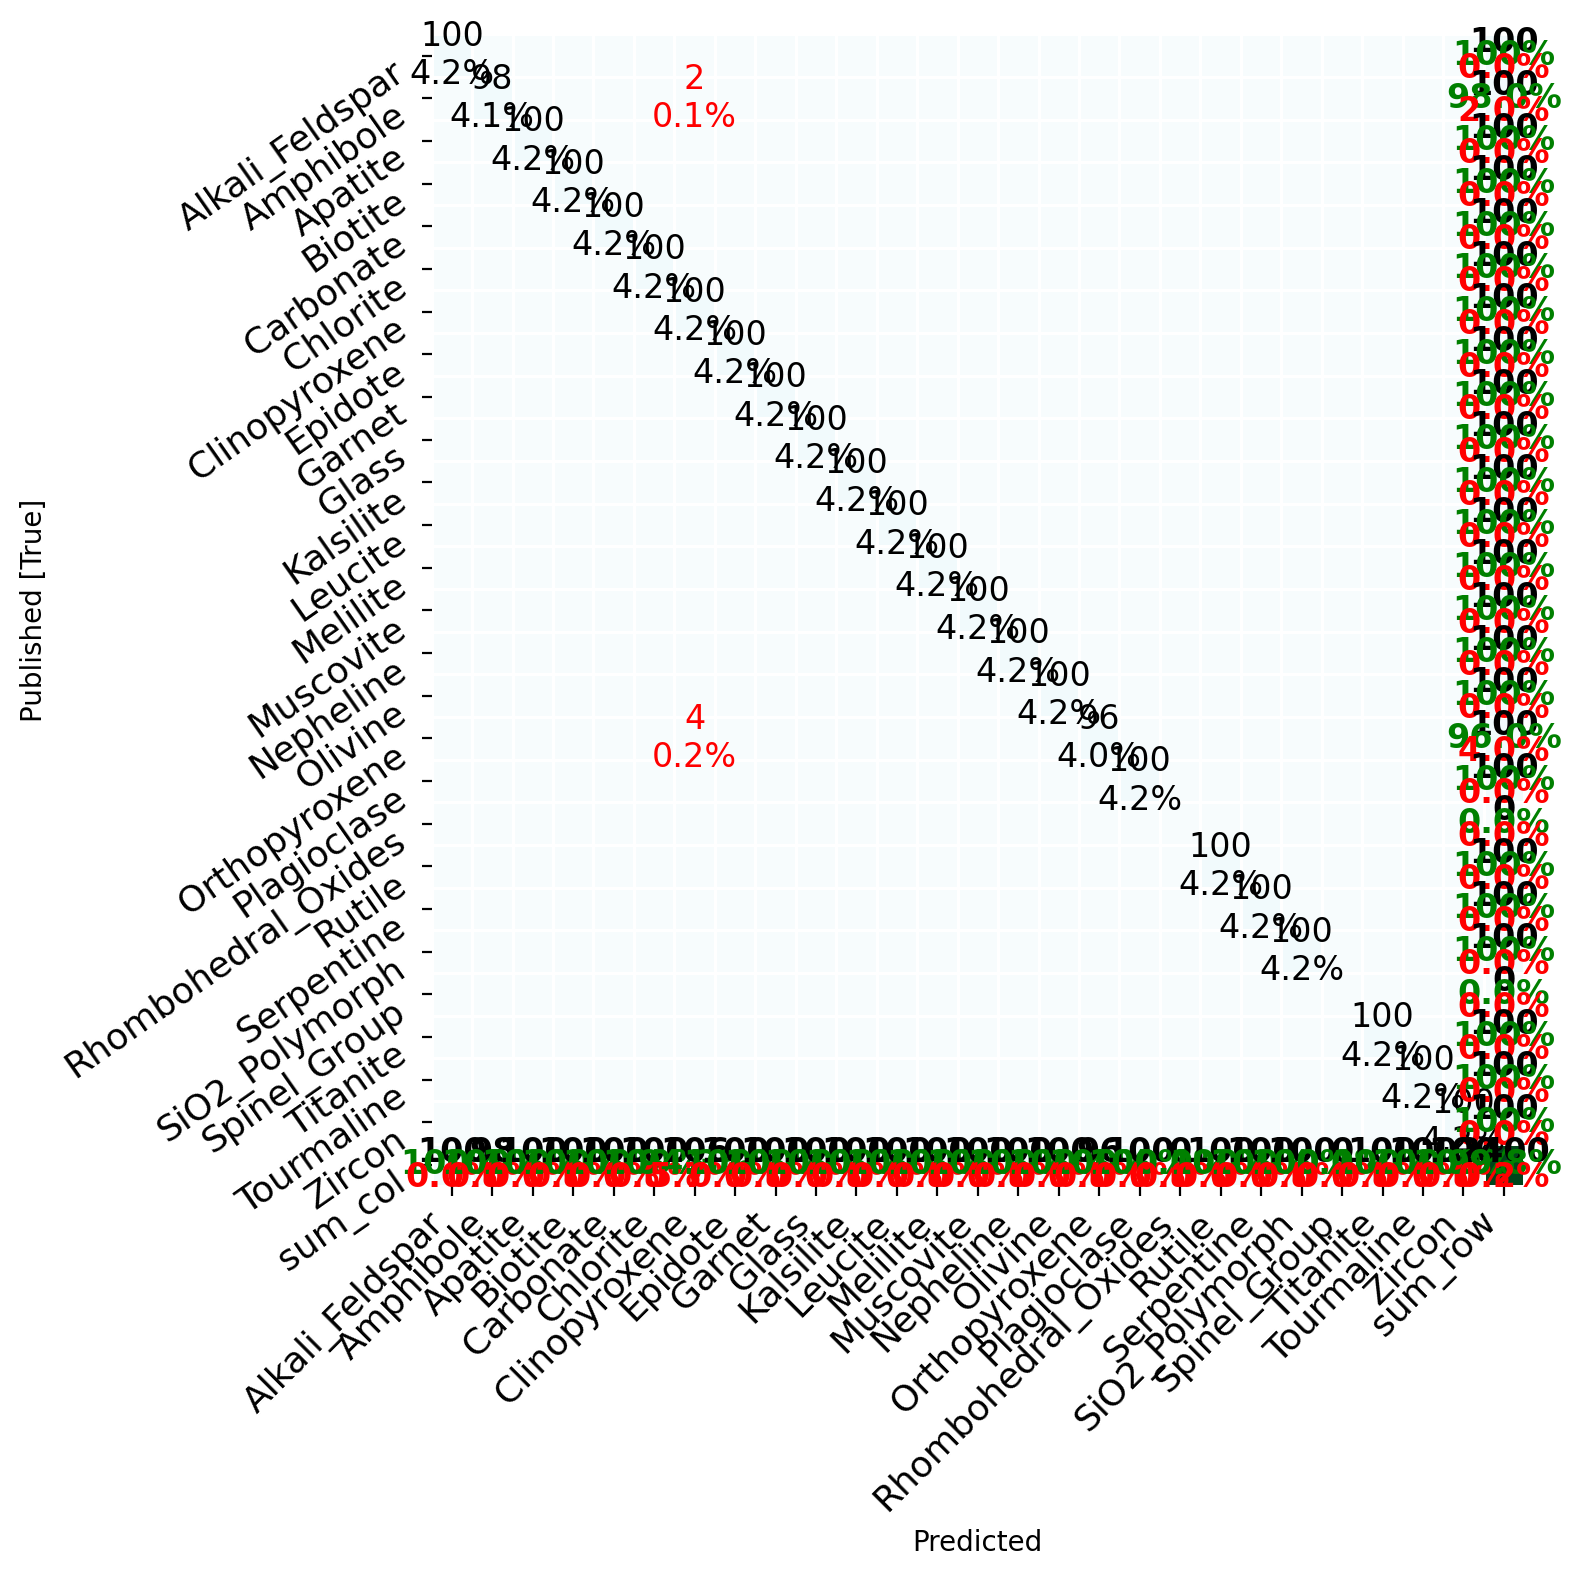

In [14]:
# Create and plot a confusion matrix 

# This compares your stated mineral and mineralML's predicted mineral
cm = mm.confusion_matrix_df(df_pred_nn['Mineral'], df_pred_nn['Predict_Mineral'])
# This plots the results in a confusion matrix
mm.pp_matrix(cm, figsize=[8, 8], savefig=None) 


Excellent, these classifications are quite promising. The most likely predicted minerals, along with their associated prediction scores with uncertainties are returned. We can further visualize these classifications in latent space.

/Users/sarahshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/hybrid.py:2326: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Zr[mask, 0], Zr[mask, 1], color=color, **ref_kws)


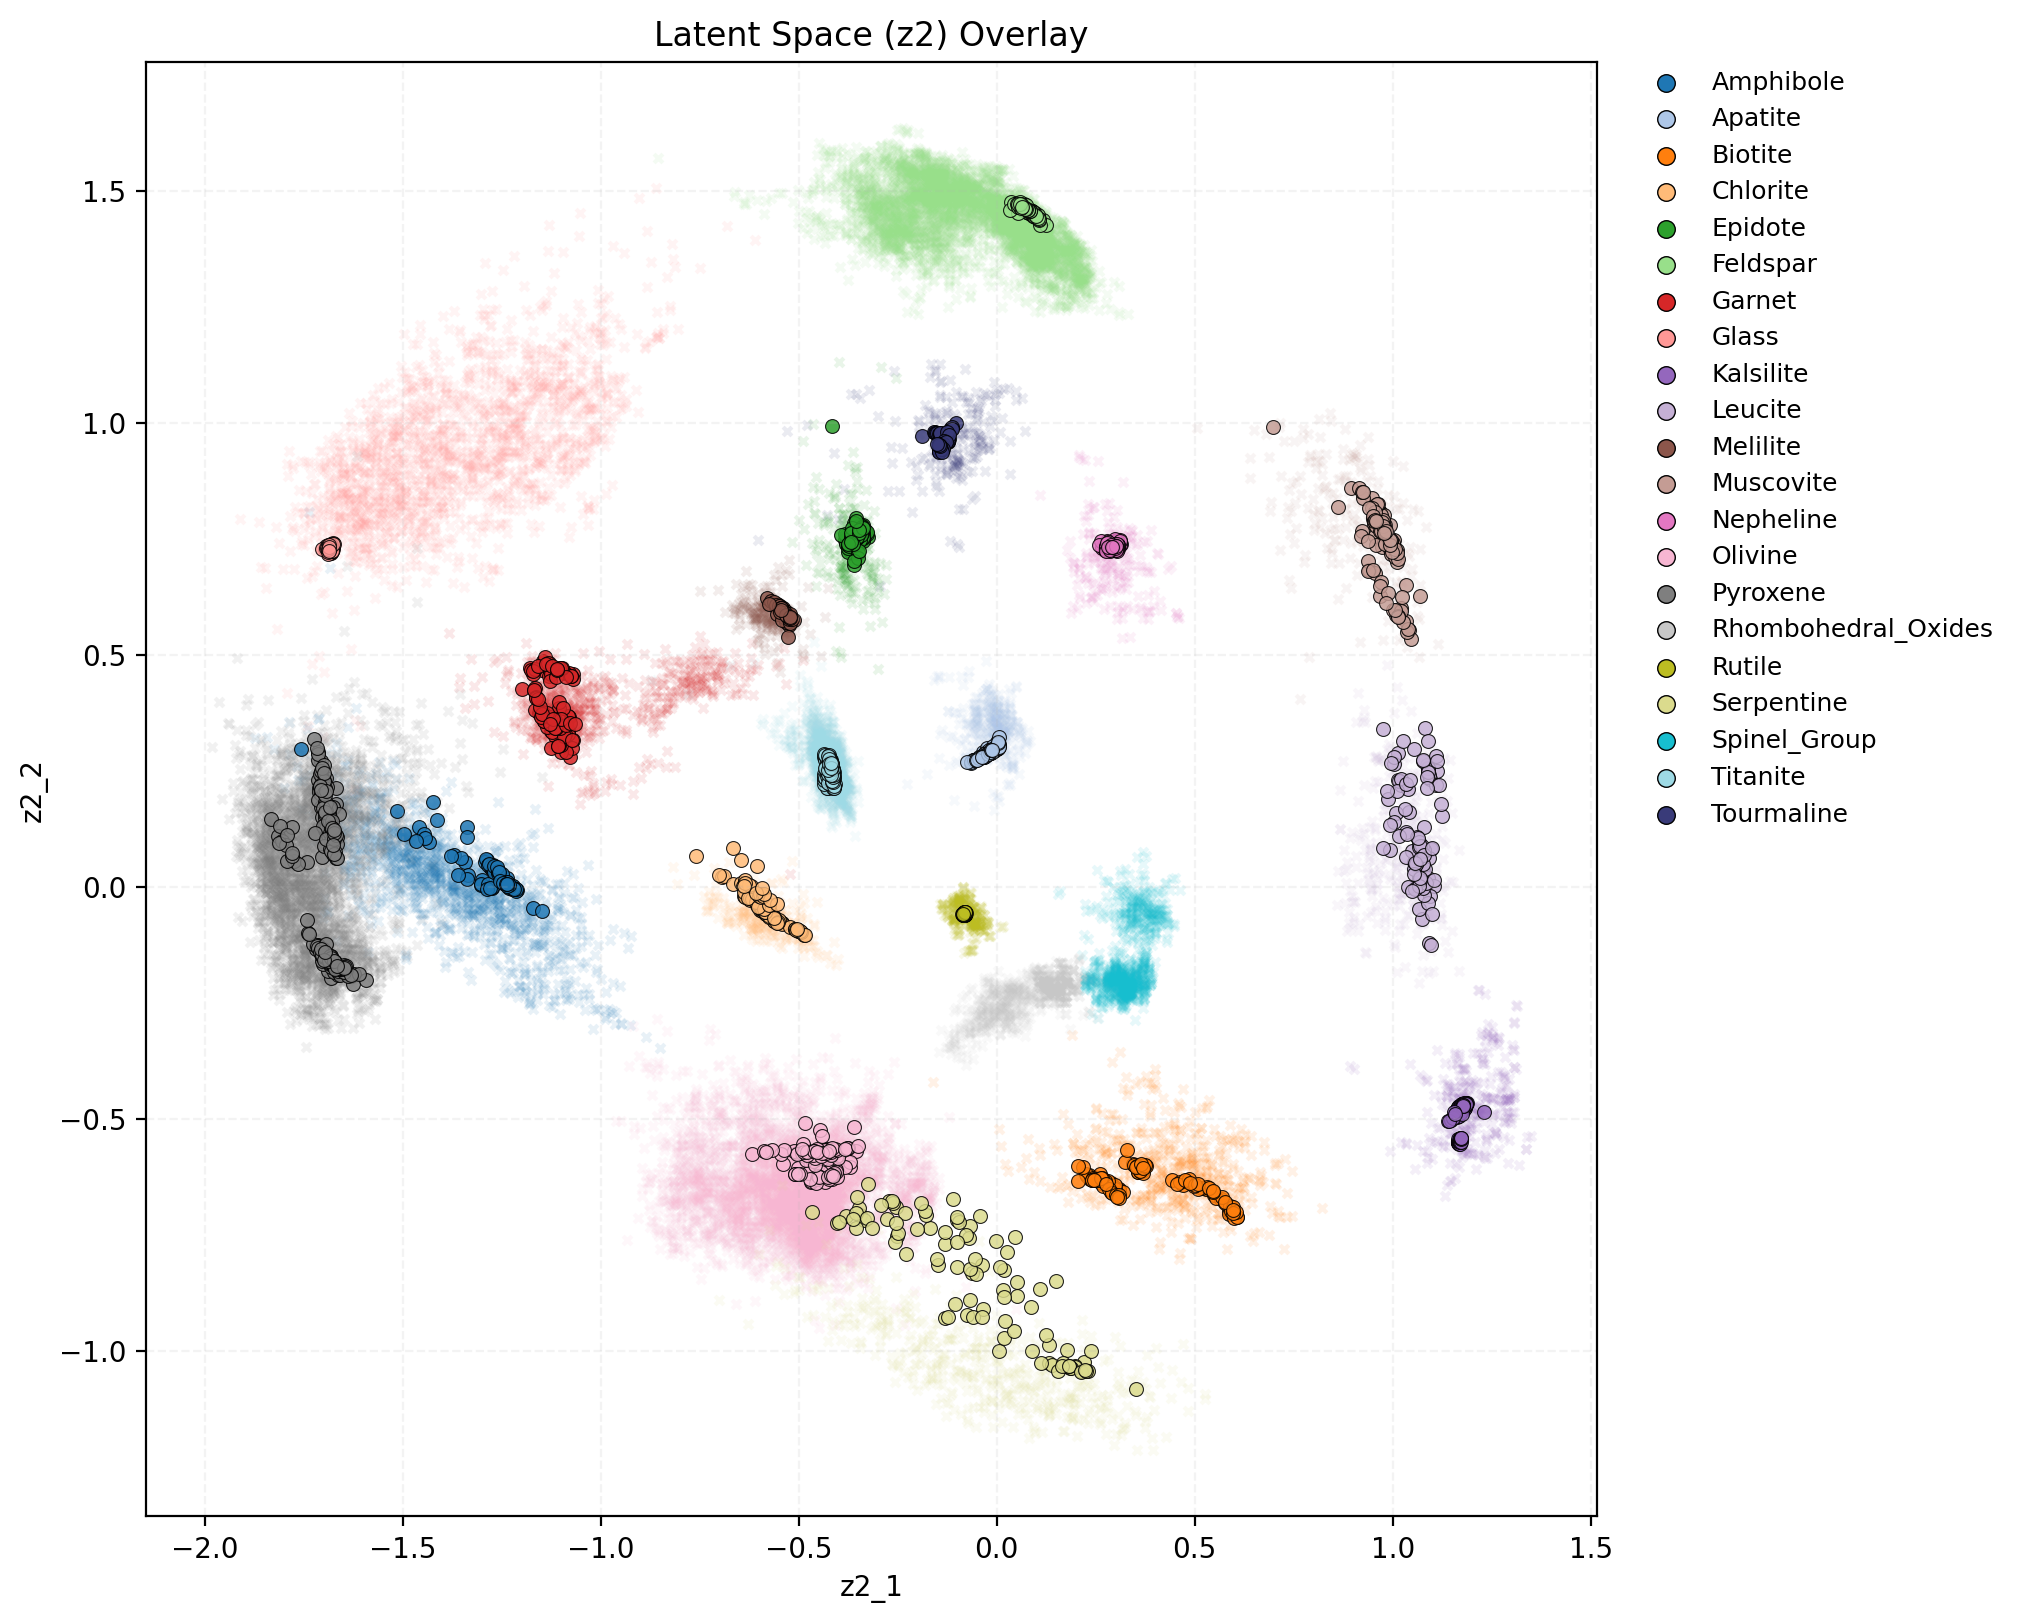

In [15]:
mm.plot_z2_overlay(df_pred_nn)

Neat! We can see where these compositions lie in latent space, and whether the predictions line up with our expected mineral phase. The points in the background are from the training and validation dataset.